In [ ]:
!make -f Makefile clean all

rm -f classifierV32 *.o
gcc classifierV32.c -D__TEST__ -Ofast -lm -o classifierV32
gcc classifierV32.c -D__TEST__ -Ofast -lm -c -o classifierV32.o


In [ ]:
!./classifierV32 < test.input > test.output_real


Всего успешно сопоставлено строк: 33870
     V  Wl    Hiri  Mode  sin_k_xy_R  cos_k_B_R  sin_k_xy_R4  sin_k_xy_R2  sin_k_xy_3R4  predicted_class
0   11  -1    13.5     2       0.289     -0.191        0.011        0.230        -0.239               15
1   13   9  1129.4     1       0.687     -0.567        0.437        0.400         0.643               24
2 -402 -22  1305.5     1       0.720     -0.603        0.537        0.417         0.680               24
3  562 -12  2384.5     1       0.810     -0.717        0.718        0.521         0.770               24
4 -492 -12  2360.8     1       0.796     -0.705        0.692        0.460         0.751               24

Количество точек, попавших в класс 21: 9552


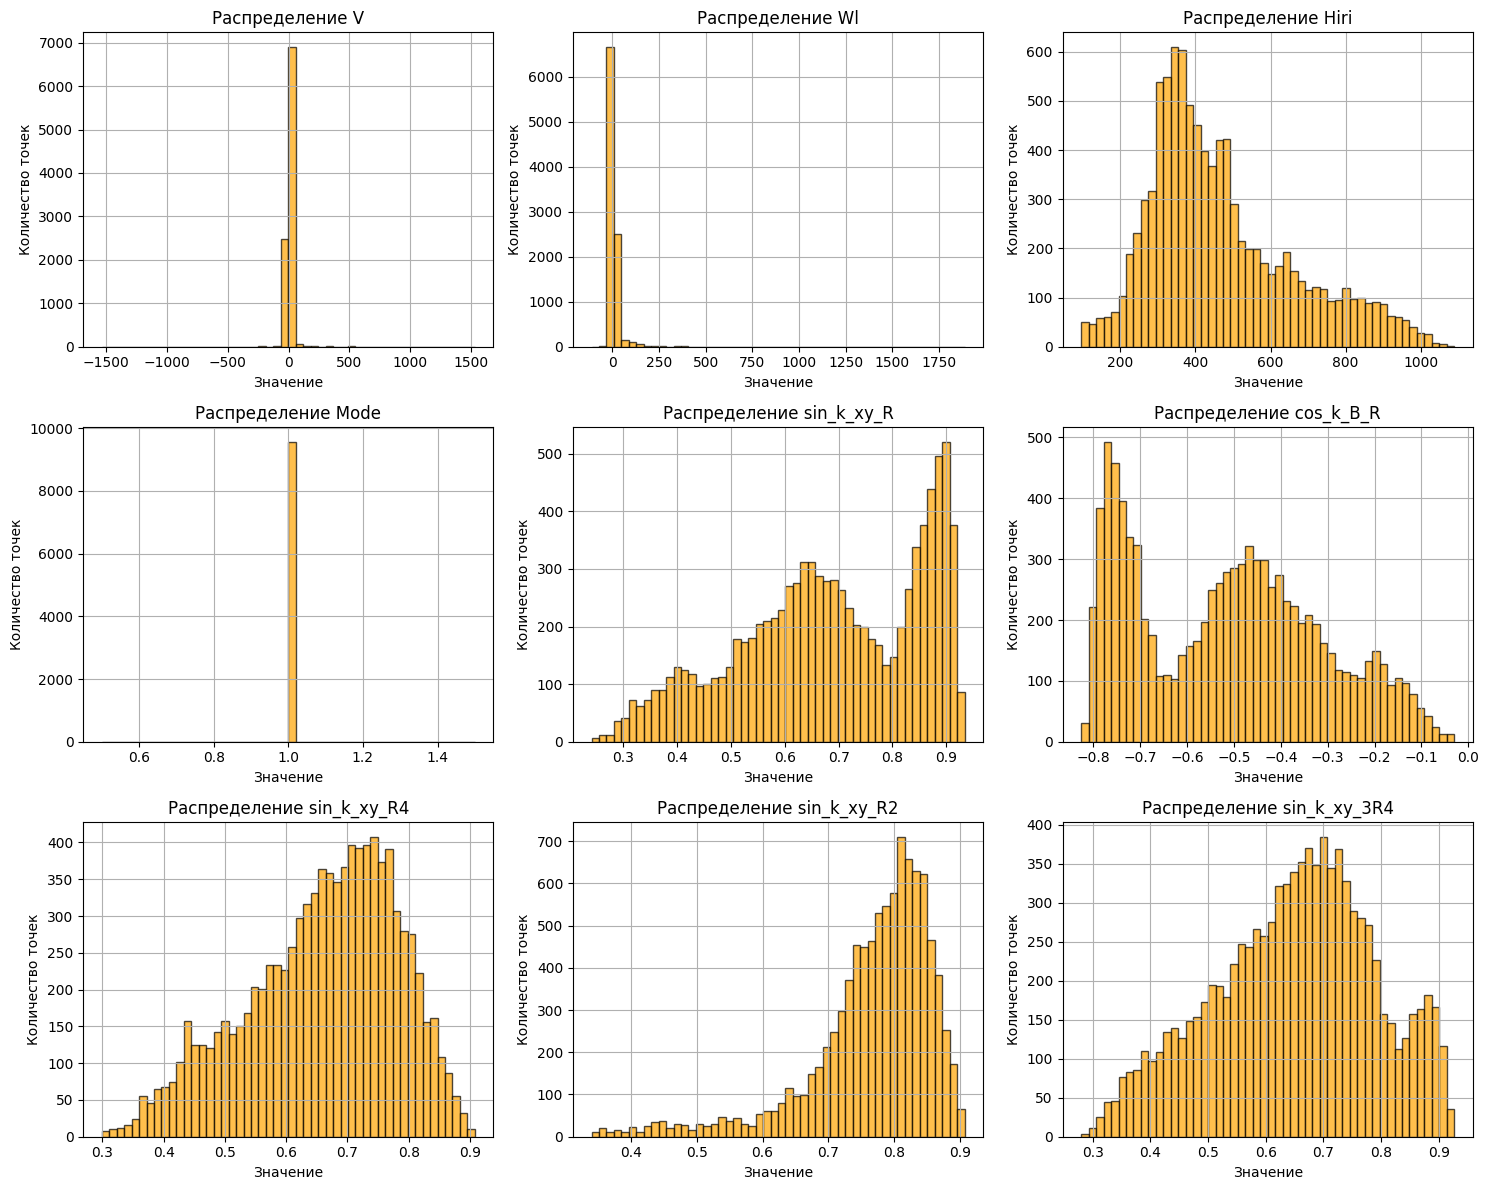

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Загрузка входных физических параметров
feature_names = ['V', 'Wl', 'Hiri', 'Mode', 'sin_k_xy_R', 'cos_k_B_R', 'sin_k_xy_R4', 'sin_k_xy_R2', 'sin_k_xy_3R4'] # В соответствии с указанными в classifierV32.c
df_input = pd.read_csv('test.input', sep=r'\s+', names=feature_names)

# Загрузка полученных классификатором классов
df_output = pd.read_csv('test.output_real', sep=r'\s+', names=['predicted_class'])

# Склейка
df_full = pd.concat([df_input, df_output], axis=1)

pd.set_option('display.max_columns', None)  # Показывать все колонки
pd.set_option('display.width', 1000)        # Увеличить макс. ширину экрана для вывода

print()
print(f"Всего успешно сопоставлено строк: {len(df_full)}")
print(df_full.head())

# 4. Выделяем строки, попавшие в смешанный класс 21
df_class_21 = df_full[df_full['predicted_class'] == 21]
print(f"\nКоличество точек, попавших в класс 21: {len(df_class_21)}")

# Постройка гистограм 21 класса
if len(df_class_21) > 0:

   plt.figure(figsize=(15, 12))

# Пробегаемся циклом по всем 9 физическим параметрам
   for i, col_name in enumerate(feature_names):

       plt.subplot(3, 3, i + 1)
    # Гистограмма для конкретного параметра
       plt.hist(df_class_21[col_name], bins=50, color='orange', alpha=0.7, edgecolor='black')

       plt.title(f'Распределение {col_name}')
       plt.xlabel('Значение')
       plt.ylabel('Количество точек')
       plt.grid(True)

   plt.tight_layout()
   plt.show()
else:
    print("\nВ тестовом датасете класс 21 не обнаружен.")

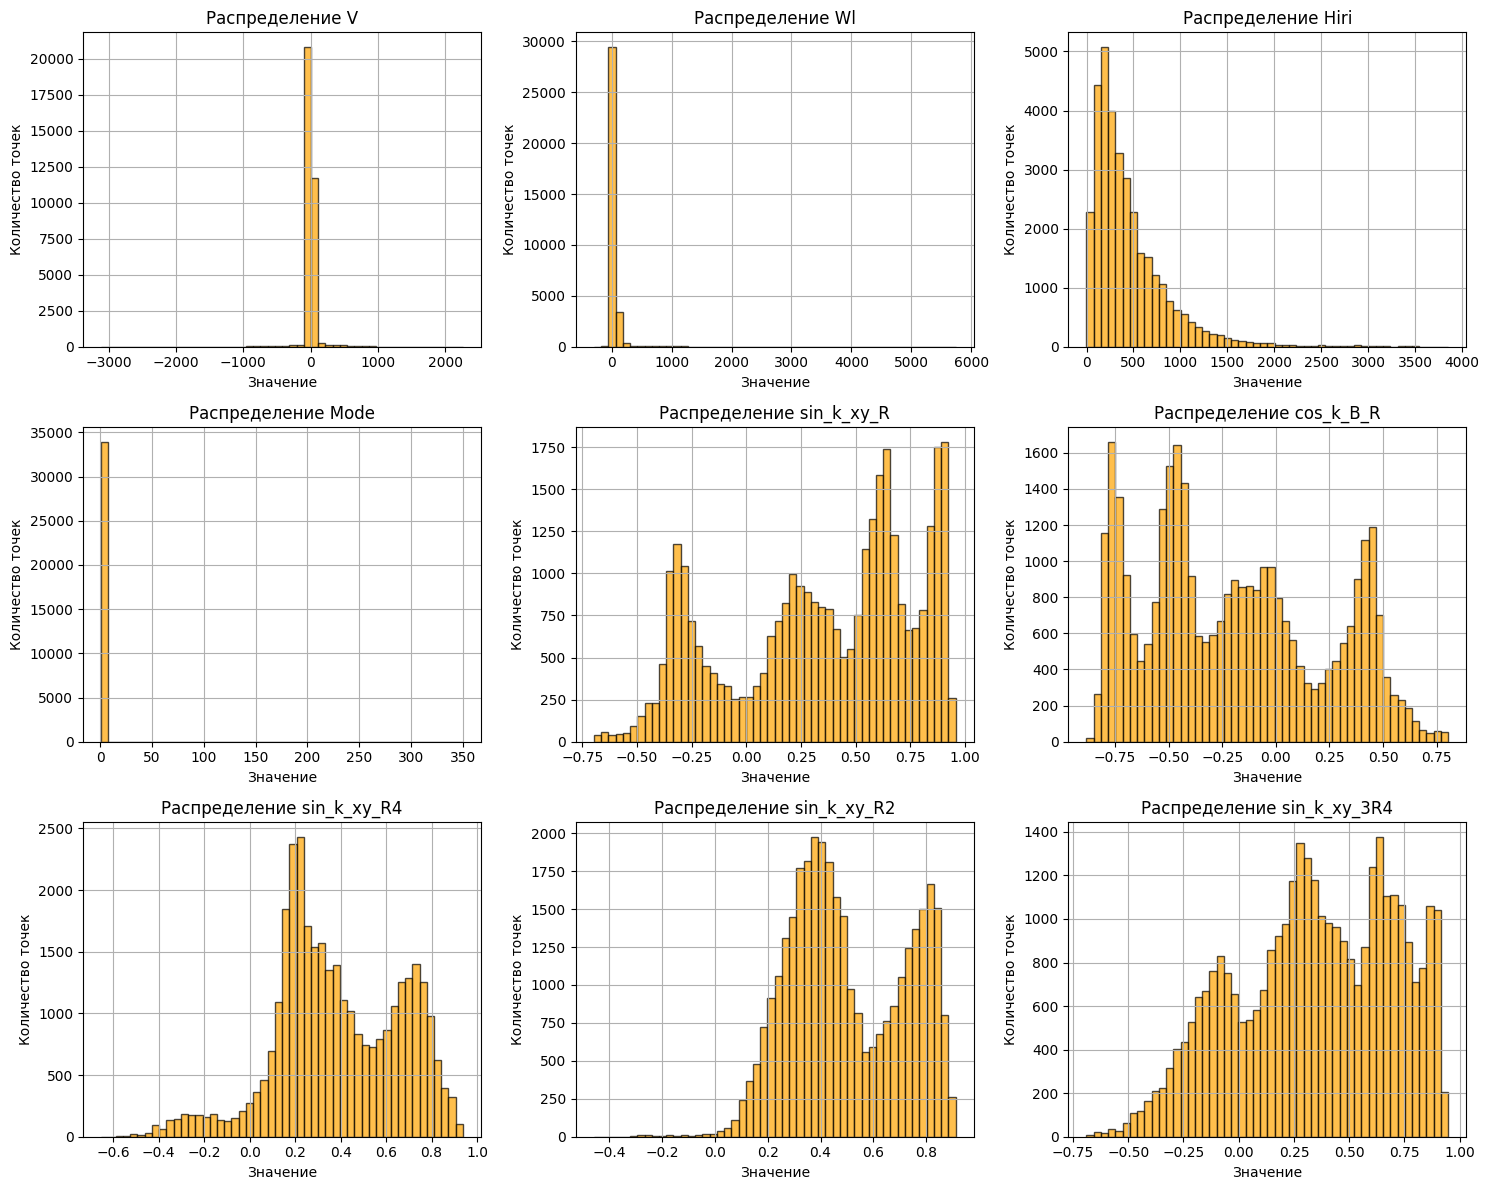

In [ ]:
plt.figure(figsize=(15, 12))

# Постройка гистограм всех точек
for i, col_name in enumerate(feature_names):

       plt.subplot(3, 3, i + 1)

    # Строим гистограмму для конкретного параметра
       plt.hist(df_full[col_name], bins=50, color='orange', alpha=0.7, edgecolor='black')

       plt.title(f'Распределение {col_name}')
       plt.xlabel('Значение')
       plt.ylabel('Количество точек')
       plt.grid(True)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1010/1565079737.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_class_21['cluster'] = kmeans.fit_predict(X_scaled)


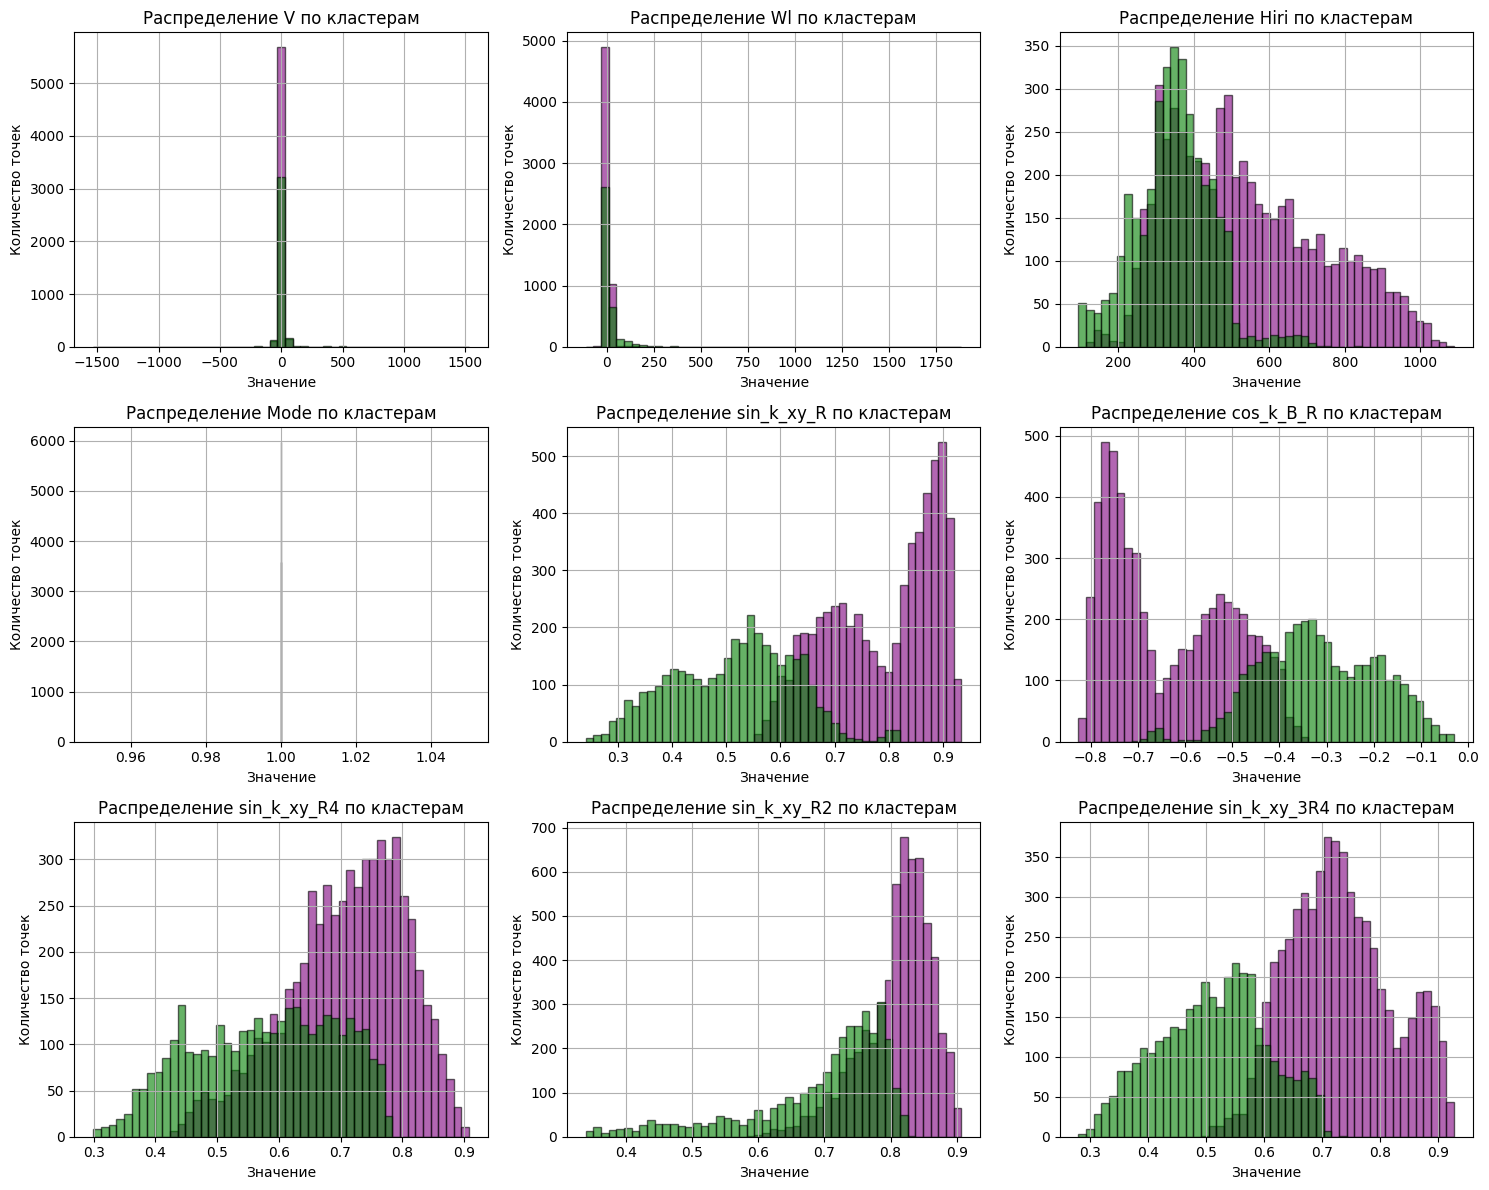

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Признаки для кластеризации
features_for_clustering = ['V', 'Wl', 'Hiri', 'Mode', 'sin_k_xy_R', 'cos_k_B_R', 'sin_k_xy_R4', 'sin_k_xy_R2', 'sin_k_xy_3R4']
X = df_class_21[features_for_clustering].copy()

# Нормирование
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Разбивание на 2 кластера
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
df_class_21['cluster'] = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(15, 12))

for i, col_name in enumerate(feature_names):
    plt.subplot(3, 3, i + 1)

    # Данные отдельно для каждого кластера
    cluster_0_data = df_class_21[df_class_21['cluster'] == 0][col_name]
    cluster_1_data = df_class_21[df_class_21['cluster'] == 1][col_name]

    bins = np.linspace(df_class_21[col_name].min(), df_class_21[col_name].max(), 50)

    plt.hist(cluster_0_data, bins=bins, color='purple', alpha=0.6, label='Кластер 0', edgecolor='black')
    plt.hist(cluster_1_data, bins=bins, color='green', alpha=0.6, label='Кластер 1', edgecolor='black')

    plt.title(f'Распределение {col_name} по кластерам')
    plt.xlabel('Значение')
    plt.ylabel('Количество точек')
    plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# Средние значения
df_means = df_class_21.groupby('cluster')[feature_names].mean().T

# Амплитуда значений
param_range = df_class_21[feature_names].max() - df_class_21[feature_names].min()

# Абсолютная разница
df_means['Abs_Difference'] = (df_means[0] - df_means[1]).abs()

# Перевод в проценты
df_means['Difference_%'] = (df_means['Abs_Difference'] / param_range) * 100

print("--- АНАЛИЗ РАЗНИЦЫ МЕЖДУ КЛАСТЕРАМИ ---")
print(df_means[[0, 1, 'Abs_Difference', 'Difference_%']].round(2))

--- АНАЛИЗ РАЗНИЦЫ МЕЖДУ КЛАСТЕРАМИ ---
cluster            0       1  Abs_Difference  Difference_%
V               3.55    4.34            0.78          0.03
Wl              6.78   20.40           13.63          0.68
Hiri          538.07  348.20          189.87         19.11
Mode            1.00    1.00            0.00           NaN
sin_k_xy_R      0.79    0.51            0.27         39.58
cos_k_B_R      -0.63   -0.32            0.31         39.54
sin_k_xy_R4     0.71    0.58            0.13         21.84
sin_k_xy_R2     0.81    0.69            0.12         20.60
sin_k_xy_3R4    0.73    0.51            0.22         34.01
